# CS 4650 Final Project
### Quantifying Linguistic Distributional Shift in Temporally Stratified MLMs

Evaluation data: https://huggingface.co/datasets/dell-research-harvard/newswire

In [1]:
!pip install -q transformers torch "datasets==2.19.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 25.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.


In [2]:
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM
from datasets import load_dataset

import matplotlib.pyplot as plt

if torch.cuda.is_available():
    DEVICE = "cuda"
else:
    DEVICE = "cpu"

print(DEVICE)

MODELS = {
    "StoriesLM-1906": {"hf_id": "StoriesLM/StoriesLM-v1-1906", "cutoff": 1906},
    "StoriesLM-1913": {"hf_id": "StoriesLM/StoriesLM-v1-1913", "cutoff": 1913},
    "StoriesLM-1919": {"hf_id": "StoriesLM/StoriesLM-v1-1919", "cutoff": 1919},
    "StoriesLM-1923": {"hf_id": "StoriesLM/StoriesLM-v1-1923", "cutoff": 1923},
    "StoriesLM-1929": {"hf_id": "StoriesLM/StoriesLM-v1-1929", "cutoff": 1929},
    "StoriesLM-1933": {"hf_id": "StoriesLM/StoriesLM-v1-1933", "cutoff": 1933},
    "StoriesLM-1939": {"hf_id": "StoriesLM/StoriesLM-v1-1939", "cutoff": 1939},
    "StoriesLM-1943": {"hf_id": "StoriesLM/StoriesLM-v1-1943", "cutoff": 1943},
    "StoriesLM-1949": {"hf_id": "StoriesLM/StoriesLM-v1-1949", "cutoff": 1949},
}

EVAL_YEARS  = [1910, 1915, 1920, 1925, 1930, 1935, 1940, 1945, 1950]
N_ARTICLES  = 300
MAX_LENGTH  = 128

cuda


## Loading Newswire Articles

In [3]:
def load_newswire_year(year: int, n: int) -> list[str]:
    dataset = load_dataset(
        "dell-research-harvard/newswire",
        data_files=f"{year}_data_clean.json",
        split="train",
        streaming=True,
    )
    articles = []

    for row in dataset:
        text = row.get("article", "").strip()

        if len(text.split()) >= 20:
            articles.append(text)
        if len(articles) >= n:
            break

    return articles

newswire_eval = {}
for year in EVAL_YEARS:
    newswire_eval[year] = load_newswire_year(year, N_ARTICLES)
    print(f"{year}: {len(newswire_eval[year])} articles")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


1910: 300 articles


1915: 300 articles
1920: 300 articles
1925: 300 articles
1930: 300 articles
1935: 300 articles
1940: 300 articles
1945: 300 articles
1950: 300 articles


## Computing Pseudo-perplexity
Source: https://arxiv.org/abs/1910.14659

$$PPPL = \exp\left(-\frac{1}{N}\sum_{i=1}^{N} \log P_{MLM}(x_i \mid x_{\setminus i})\right)$$

Where $x_{\setminus i}$is the input sequence with the target token masked

In [4]:
def pseudo_perplexity(model, tokenizer, text: str, max_length: int = MAX_LENGTH, sample_every: int = 1) -> float:
    encodings = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
    ).to(DEVICE)

    input_ids = encodings["input_ids"]
    seq_len   = input_ids.shape[1]

    mask_positions = list(range(1, seq_len - 1, sample_every))
    if not mask_positions:
        return float("nan")

    total_loss = 0.0
    count = 0

    for pos in mask_positions:
        masked_input = input_ids.clone()
        true_token   = input_ids[0, pos].item()
        masked_input[0, pos] = tokenizer.mask_token_id

        with torch.no_grad():
            logits = model(masked_input, attention_mask=encodings["attention_mask"]).logits

        log_probs  = torch.nn.functional.log_softmax(logits[0, pos], dim=-1)
        token_loss = -log_probs[true_token].item()
        total_loss += token_loss
        count += 1

    mean_loss = total_loss / count
    return float(np.exp(mean_loss))


def eval_pppl_for_year(model, tokenizer, articles: list[str], sample_every: int = 3) -> float:
    #median PPPL
    scores = []
    for text in articles:
        score = pseudo_perplexity(model, tokenizer, text, sample_every=sample_every)
        if not np.isnan(score):
            scores.append(score)
    #return float(np.mean(scores))
    return float(np.median(scores))

## Evaluate all models on every year

In [5]:
import json

results = {}

for model_name, meta in MODELS.items():
    print(f"\n{'='*50}")
    print(f"{model_name} | cutoff: {meta['cutoff']}")
    print(f"{'='*50}")

    tokenizer = AutoTokenizer.from_pretrained(meta["hf_id"])
    model =     AutoModelForMaskedLM.from_pretrained(meta["hf_id"]).to(DEVICE)
    model.eval()

    results[model_name] = {}
    for year in EVAL_YEARS:
        pppl = eval_pppl_for_year(model, tokenizer, newswire_eval[year])
        results[model_name][year] = round(pppl, 2)

        if year <= meta["cutoff"]:
            print(f"{year} [IN]  PPPL = {pppl:.2f}")
        else:
            print(f"{year} [OOD] PPPL = {pppl:.2f}")

    del model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

with open("mlm_pppl_results.json", "w") as f:
    json.dump(results, f, indent=2)
print("\nResults saved to mlm_pppl_results.json")


StoriesLM-1906 | cutoff: 1906


config.json:   0%|          | 0.00/639 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

1910 [IN]  PPPL = 5.55
1915 [IN]  PPPL = 5.75
1920 [IN]  PPPL = 12.63
1925 [IN]  PPPL = 10.79
1930 [IN]  PPPL = 10.80
1935 [IN]  PPPL = 11.91
1940 [IN]  PPPL = 11.07
1945 [IN]  PPPL = 9.94
1950 [OOD] PPPL = 11.43

Results saved to mlm_pppl_results.json


## Results

In [6]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "model"
print(df.to_string())

                1910  1915   1920   1925   1930   1935   1940   1945   1950
model                                                                      
StoriesLM-1906  6.93  8.43  18.83  18.39  20.94  27.70  32.44  38.34  45.90
StoriesLM-1913  4.85  5.64  12.47  13.31  15.09  19.57  25.17  28.71  33.52
StoriesLM-1919  4.77  4.19  10.35  10.74  12.09  15.74  16.32  18.16  22.15
StoriesLM-1923  4.73  4.56   9.46   9.35  10.79  13.70  15.74  17.54  21.33
StoriesLM-1929  4.84  4.82  10.29   9.06   9.68  13.45  14.67  17.67  21.57
StoriesLM-1933  4.87  4.96  10.40   9.19   9.81  11.56  13.20  15.56  19.52
StoriesLM-1939  5.13  5.07  11.28   9.83   9.98  10.05  10.15  13.55  16.14
StoriesLM-1943  5.35  5.18  11.91  10.37  10.71  11.07   9.76  11.35  14.86
StoriesLM-1949  5.55  5.75  12.63  10.79  10.80  11.91  11.07   9.94  11.43


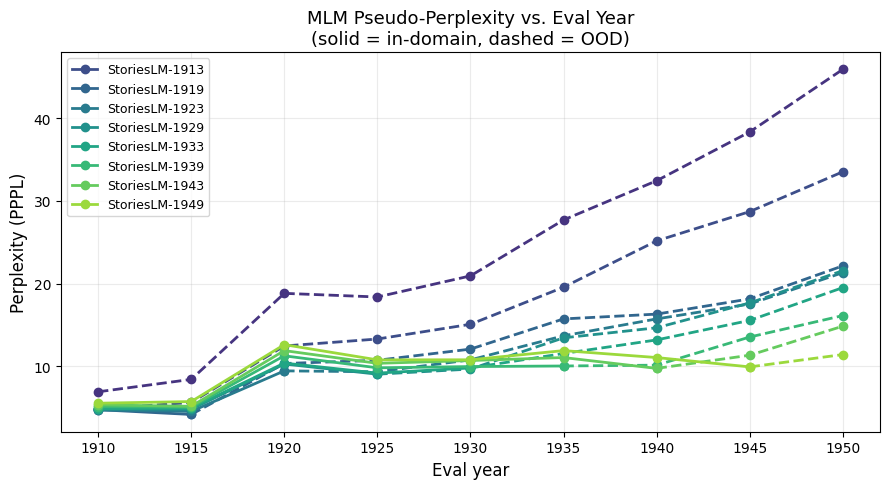

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
colors  = plt.cm.viridis(np.linspace(0.15, 0.85, len(MODELS)))

for (model_name, meta), color in zip(MODELS.items(), colors):
    cutoff    = meta["cutoff"]
    years     = sorted(EVAL_YEARS)
    pppls     = [results[model_name][y] for y in years]
    in_years  = [y for y in years if y <= cutoff]
    ood_years = [y for y in years if y >  cutoff]
    in_pppls  = [results[model_name][y] for y in in_years]
    ood_pppls = [results[model_name][y] for y in ood_years]

    if in_years:
        ax.plot(in_years, in_pppls, color=color, lw=2, marker="o", label=model_name)
    if ood_years:
        bridge_x = ([in_years[-1]]  if in_years  else []) + ood_years
        bridge_y = ([in_pppls[-1]]  if in_pppls  else []) + ood_pppls
        ax.plot(bridge_x, bridge_y, color=color, lw=2, marker="o", linestyle="--")
    if cutoff in years:
        ax.axvline(x=cutoff, color=color, lw=0.6, alpha=0.35, linestyle=":")

ax.set_xlabel("Eval year", fontsize=12)
ax.set_ylabel("Perplexity (PPPL)", fontsize=12)
ax.set_title("MLM Pseudo-Perplexity vs. Eval Year\n(solid = in-domain, dashed = OOD)", fontsize=13)

ax.legend(fontsize=9, loc="upper left")
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig("mlm_pppl.png", dpi=150)
plt.show()

## Sentence Ordering Probe

In [8]:
import numpy as np
import nltk

from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier

nltk.download("punkt_tab", quiet=True)
from nltk.tokenize import sent_tokenize


# Data processing
def extract_sentence_pairs(
    articles: list[str],
    n_pairs_per_article: int = 4,
    min_words: int = 8,
) -> list[tuple[str, str, int]]:
    pairs = []
    for article in articles:
        sentences = sent_tokenize(article)

        sentences = [s.strip() for s in sentences if len(s.split()) >= min_words]
        if len(sentences) < 2:
            continue

        indices = list(range(len(sentences) - 1))
        np.random.shuffle(indices)

        for i in indices[:n_pairs_per_article]:
            s1, s2 = sentences[i], sentences[i + 1]
            pairs.append((s1, s2, 1))
            pairs.append((s2, s1, 0))

    return pairs


# Extract embeddings from last layer
def mean_pool(
    model,
    tokenizer,
    text: str,
    max_length: int = MAX_LENGTH,
) -> np.ndarray:
    # mean pool over (non-padding) token hidden states of final layer
    enc = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length,
        padding="max_length",
    ).to(DEVICE)

    with torch.no_grad():
        out = model(**enc)

    mask = enc["attention_mask"].unsqueeze(-1).float()  # (1, N, 1)
    hidden = out.last_hidden_state                       # (1, N, D)
    pooled = (hidden * mask).sum(1) / mask.sum(1)        # (1, D)

    return pooled[0].cpu().numpy()

# Build input for classifier
def build_feature_matrix(
    model,
    tokenizer,
    pairs: list[tuple[str, str, int]],
) -> tuple[np.ndarray, np.ndarray]:
    # x = concat(emb(s1), emb(s2)).
    X, y = [], []
    for s1, s2, label in pairs:
        e1 = mean_pool(model, tokenizer, s1)
        e2 = mean_pool(model, tokenizer, s2)
        X.append(np.concatenate([e1, e2]))
        y.append(label)

    return np.array(X), np.array(y)

In [9]:
def run_probe(
    model_name: str,
    newswire_eval: dict[int, list[str]],
    eval_years: list[int],
    n_pairs_per_article: int = 4,
) -> dict[int, float]:
    # Classifier is only trained on in-domain sentence pairs
    meta = MODELS[model_name]
    cutoff = meta["cutoff"]

    print(f"\n{'='*50}")
    print(f"Sentence Ordering Probe — {model_name}  (cutoff: {cutoff})")
    print(f"{'='*50}")

    # Load model
    tokenizer = AutoTokenizer.from_pretrained(meta["hf_id"])
    model = AutoModel.from_pretrained(meta["hf_id"]).to(DEVICE)
    model.eval()

    # Build train set (ONLY in-domain)
    in_domain_years = [y for y in eval_years if y <= cutoff]
    if not in_domain_years:
        print(f"skipping {model_name}")

        del model
        torch.cuda.empty_cache() if DEVICE == "cuda" else None
        return {}

    print(f"  Training on in-domain years: {in_domain_years}")
    train_pairs = []

    for year in in_domain_years:
        train_pairs.extend(
            extract_sentence_pairs(newswire_eval[year], n_pairs_per_article)
        )
    print(f"  Total training pairs: {len(train_pairs)}")
    X_train, y_train = build_feature_matrix(model, tokenizer, train_pairs)

    # Train classifier
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    clf = LogisticRegression(max_iter=999)
    clf.fit(X_train_sc, y_train)

    # Baseline
    dummy = DummyClassifier(strategy="most_frequent")
    dummy.fit(X_train_sc, y_train)

    accuracies = {}
    for year in eval_years:
        test_pairs = extract_sentence_pairs(
            newswire_eval[year], n_pairs_per_article
        )
        if not test_pairs:
            continue

        X_test, y_test = build_feature_matrix(model, tokenizer, test_pairs)
        X_test_sc = scaler.transform(X_test)
        acc = clf.score(X_test_sc, y_test)
        accuracies[year] = round(acc, 4)

        if year <= cutoff:
            print(f"{year} [IN]  accuracy = {acc:.3f}  (n_pairs={len(test_pairs)})")
        else:
            print(f"{year} [OOD] accuracy = {acc:.3f}  (n_pairs={len(test_pairs)})")

    del model
    torch.cuda.empty_cache() if DEVICE == "cuda" else None

    return accuracies

### Results

In [10]:
so_results = {}   # r[model_name][eval_year] = accuracy

for model_name in MODELS:
    so_results[model_name] = run_probe(
        model_name,
        newswire_eval,
        EVAL_YEARS,
    )


Sentence Ordering Probe — StoriesLM-1906  (cutoff: 1906)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: StoriesLM/StoriesLM-v1-1906
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


skipping StoriesLM-1906

Sentence Ordering Probe — StoriesLM-1913  (cutoff: 1913)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

...

BertModel LOAD REPORT from: StoriesLM/StoriesLM-v1-1943
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Training on in-domain years: [1910, 1915, 1920, 1925, 1930, 1935, 1940]
  Total training pairs: 12236
1910 [IN]  accuracy = 0.619  (n_pairs=1974)
1915 [IN]  accuracy = 0.678  (n_pairs=1806)
1920 [IN]  accuracy = 0.743  (n_pairs=1242)
1925 [IN]  accuracy = 0.682  (n_pairs=1604)
1930 [IN]  accuracy = 0.665  (n_pairs=1940)
1935 [IN]  accuracy = 0.667  (n_pairs=1818)
1940 [IN]  accuracy = 0.699  (n_pairs=1852)
1945 [OOD] accuracy = 0.622  (n_pairs=1898)
1950 [OOD] accuracy = 0.599  (n_pairs=2218)

Sentence Ordering Probe — StoriesLM-1949  (cutoff: 1949)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: StoriesLM/StoriesLM-v1-1949
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Training on in-domain years: [1910, 1915, 1920, 1925, 1930, 1935, 1940, 1945]
  Total training pairs: 14134
1910 [IN]  accuracy = 0.641  (n_pairs=1974)
1915 [IN]  accuracy = 0.626  (n_pairs=1806)
1920 [IN]  accuracy = 0.702  (n_pairs=1242)
1925 [IN]  accuracy = 0.687  (n_pairs=1604)
1930 [IN]  accuracy = 0.660  (n_pairs=1940)
1935 [IN]  accuracy = 0.691  (n_pairs=1818)
1940 [IN]  accuracy = 0.688  (n_pairs=1852)
1945 [IN]  accuracy = 0.665  (n_pairs=1898)
1950 [OOD] accuracy = 0.597  (n_pairs=2218)


In [26]:
print(f"{'Model':<20}" + "".join(f"{y:>8}" for y in EVAL_YEARS))
for model_name, meta in MODELS.items():
    if not so_results[model_name]:
        continue

    cutoff = meta["cutoff"]
    row = f"{model_name:<20}"
    for year in EVAL_YEARS:
        acc = so_results.get(model_name, {}).get(year)
        cell = f"{acc:.2f}"
        row += f"{"*" if year <= cutoff else " "}{cell:>6} "
    print(row)

Model                   1910    1915    1920    1925    1930    1935    1940    1945    1950
StoriesLM-1913      *  0.76    0.59    0.62    0.61    0.59    0.58    0.60    0.59    0.56 
StoriesLM-1919      *  0.70 *  0.73    0.64    0.61    0.62    0.60    0.63    0.60    0.59 
StoriesLM-1923      *  0.65 *  0.68 *  0.78    0.62    0.62    0.62    0.61    0.59    0.58 
StoriesLM-1929      *  0.66 *  0.68 *  0.77 *  0.71    0.64    0.63    0.63    0.63    0.59 
StoriesLM-1933      *  0.64 *  0.67 *  0.73 *  0.69 *  0.66    0.64    0.64    0.62    0.62 
StoriesLM-1939      *  0.63 *  0.66 *  0.74 *  0.69 *  0.68 *  0.69    0.66    0.63    0.60 
StoriesLM-1943      *  0.62 *  0.68 *  0.74 *  0.68 *  0.66 *  0.67 *  0.70    0.62    0.60 
StoriesLM-1949      *  0.64 *  0.63 *  0.70 *  0.69 *  0.66 *  0.69 *  0.69 *  0.66    0.60 


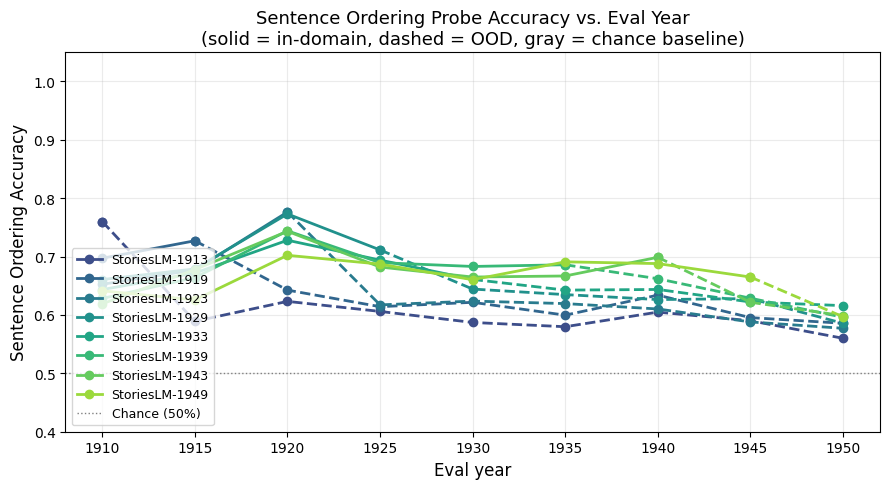

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(MODELS)))

for (model_name, meta), color in zip(MODELS.items(), colors):
    cutoff = meta["cutoff"]
    accs = so_results.get(model_name, {})
    if not accs:
        continue

    years = sorted(accs.keys())
    vals = [accs[y] for y in years]
    in_years  = [y for y in years if y <= cutoff]
    ood_years = [y for y in years if y >  cutoff]
    in_vals   = [accs[y] for y in in_years]
    ood_vals  = [accs[y] for y in ood_years]

    if in_years:
        ax.plot(in_years, in_vals, color=color, lw=2, marker="o", label=model_name)
    if ood_years:
        bridge_x = ([in_years[-1]] if in_years else []) + ood_years
        bridge_y = ([in_vals[-1]]  if in_vals  else []) + ood_vals
        ax.plot(bridge_x, bridge_y, color=color, lw=2, marker="o", linestyle="--")
    if cutoff in years:
        ax.axvline(x=cutoff, color=color, lw=0.6, alpha=0.35, linestyle=":")

ax.axhline(y=0.5, color="gray", lw=1.0, linestyle=":", label="Chance (50%)")
ax.set_xlabel("Eval year", fontsize=12)
ax.set_ylabel("Sentence Ordering Accuracy", fontsize=12)
ax.set_title(
    "Sentence Ordering Probe Accuracy vs. Eval Year\n"
    "(solid = in-domain, dashed = OOD, gray = random baseline)",
    fontsize=13,
)
ax.legend(fontsize=9, loc="lower left")
ax.set_ylim(0.4, 1.05)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


### Data Samples

In [16]:
import textwrap

PREVIEW_YEARS =  [1910, 1920, 1930, 1940, 1950]
SAMPLES_PER_YEAR = 2

for year in PREVIEW_YEARS:
    print(f"\n{'='*50}")
    print(f"Newswire {year} (N={len(newswire_eval[year])} articles loaded)")
    print(f"{'='*50}")
    for i, article in enumerate(newswire_eval[year][:SAMPLES_PER_YEAR]):
        preview = textwrap.fill(article[:400], width=70)
        print(f"\n[Sample {i+1}]\n{preview}{'...' if len(article) > 400 else ''}")



Newswire 1910 (N=300 articles loaded)

[Sample 1]
Washington, Jan. s. President Taft today sent to the senate the
nomination of the members of the new court Of customs appeals
authorized under the Payne tariff law, as fol- lows:   To be presiding
judge. Alfred c. Coke, at present United States circuit Judge of the
second circuit.   l. To be associate judges, William H. Hunt, at
present United States Judge for the district Of Montana, James F. Smi...

[Sample 2]
WASHINGTON, Fob. 9.-The president sent to the senate today the
nomination OF Grant T, Trent OF Tennessee. 10 be an associate Justice
OF the supreme court OF the Philippine islands   President Taft also
sent 10 the senate today the nomination OF Frederick J ". kraokc. to
be naval officer of customs at New York

Newswire 1920 (N=300 articles loaded)

[Sample 1]
LONDON, Sept. 22.—-Terence Mac-  Swiney today began the 41st day of
his hunger strike there being no change from his condition of yester-
day according to the report to th